# PROJECT TITLE: WAREHOUSE INVENTORY OPTIMIZATION AND SEGMENTATION

#  Project Overview
This project analyzes a warehouse inventory dataset containing **1000 product records** across multiple warehouses.  
The goal is to clean messy inventory data, uncover operational insights, and use unsupervised machine learning to segment products and warehouses for better stock management and cost reduction.

The dataset tracks product details such as **Product ID, Product Name, Category, Warehouse, Location, Quantity, Price, Supplier, Status, and Last Restocked date**.  
The raw data is messy with incorrect data types and missing values.

# Problem Statement
Warehouses often struggle with 3 key problems:
1. **Overstock**: Capital tied up in products that do not sell
2. **Stockouts**: Lost sales due to "Out of Stock" on popular items
3. **Inefficient Warehousing**: Lack of segmentation leads to treating all products and warehouses the same

This results in wasted space, expired stock, and poor reordering decisions.

## Aims/Objectives of the Project
1. **Data Cleaning**: Fix data types, handle missing values, and standardize text
2. **Exploratory Data Analysis**: Identify top categories, slow-moving stock, and warehouse performance
3. **Unsupervised Segmentation**: Group products and warehouses by behavior to find hidden patterns
4. **Actionable Insights**: Provide recommendations on what to restock, discount, or relocate



# Data Understanding

**Data Source**: [Kaggle](https://github.com/eyowhite/Messy-dataset/blob/main/warehouse_messy_data.csv)
The dataset contains warehouse inventory records. It has **1000 rows** and **10 columns**.  

### **Column Descriptions:**
1. **Product ID**:Unique identifier for each product in the inventory.
2. **Product Name**:Name of the product. Examples: "Gadget Y", "Widget A". May have inconsistent capitalization and spacing.
3. **Category**:The product category or type. Used to group similar products together.
4. **Warehouse**: Name of the warehouse where the product is stored.
5. **Location**:Specific location/shelf/bin within the warehouse.
6. **Quantity**:Current stock quantity of the product.
7. **Price**:Unit price of the product in currency.
8. **Supplier**:Name of the supplier or vendor who provides the product.
9. **Status**:Stock status of the product. Expected values: "In Stock", "Out of Stock".
10. **Last Restocked**:Date when the product was last restocked.

In [20]:
#Import necessary libraries
import numpy as np
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('warehouse_messy_data.csv')

#Check the first five rows of the DataFrame
print("Head:")
print(df.head())

#Check dataset info - data types, missing values, memory
print("INFO:")
df.info()

#STATISTICAL SUMMARY - for numeric columns
print("DESCRIBE NUMERIC:")
print(df.describe())

# STATISTICAL SUMMARY - for categorical columns too
print("DESCRIBE CATEGORICAL:")
print(df.describe(include='object'))

Head:
   Product ID Product Name     Category    Warehouse Location     Quantity  \
0        1102    gadget y   ELECTRONICS  Warehouse 2  Aisle 1          300   
1        1435    gadget y   ELECTRONICS  Warehouse 2  Aisle 4  two hundred   
2        1860    widget a      CLOTHING  Warehouse 2  Aisle 3          100   
3        1270    gadget z          TOYS  Warehouse 2  Aisle 4           50   
4        1106    widget a     FURNITURE  Warehouse 3  Aisle 3  two hundred   

   Price    Supplier        Status Last Restocked  
0   9.99  Supplier C      In Stock            NaN  
1  19.99  Supplier C  Out of Stock            NaN  
2  19.99  Supplier B      In Stock     20/12/2022  
3  49.99  Supplier B      In Stock     20/12/2022  
4   9.99  Supplier D  Out of Stock     25/04/2023  
INFO:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product ID      1

C:\Users\frkuhn\AppData\Local\Temp\ipykernel_8996\1570128282.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object'))


# Data Cleaning


In [21]:
# Fix Data Types
# Convert Quantity column to numeric, coercing errors to NaN
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

#Convert last_restock_date to datetime, coercing errors to NaT
df['Last Restocked'] = pd.to_datetime(df['Last Restocked'], format='%d/%m/%Y', errors='coerce')

 # Check the data types again to confirm changes
print("\nINFO AFTER FIXING DATA TYPES:")
print(df.info())


INFO AFTER FIXING DATA TYPES:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Product ID      1000 non-null   int64         
 1   Product Name    1000 non-null   str           
 2   Category        1000 non-null   str           
 3   Warehouse       1000 non-null   str           
 4   Location        1000 non-null   str           
 5   Quantity        682 non-null    float64       
 6   Price           793 non-null    float64       
 7   Supplier        1000 non-null   str           
 8   Status          1000 non-null   str           
 9   Last Restocked  800 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 78.3 KB
None


In [22]:
#Check for missing values in the DataFrame
df.isnull().sum()

Product ID          0
Product Name        0
Category            0
Warehouse           0
Location            0
Quantity          318
Price             207
Supplier            0
Status              0
Last Restocked    200
dtype: int64

In [23]:
#Handle missing values
#Quantity: Fill missing values with 0;meaning that if the quantity is missing, we assume it is out of stock
df = df.fillna({'Quantity': 0})

#Last Restocked: Fill missing values with the earliest date in the dataset; this assumes that if we don't know when it was last restocked, it was a long time ago
df = df.fillna({'Last Restocked': df['Last Restocked'].min()})

#Price: Fill missing values with the median price; this is a common practice to avoid skewing the data with extreme values
df = df.fillna({'Price': df['Price'].median()})


In [24]:
#Check for missing values again to confirm that they have been handled
df.isnull().sum()

Product ID        0
Product Name      0
Category          0
Warehouse         0
Location          0
Quantity          0
Price             0
Supplier          0
Status            0
Last Restocked    0
dtype: int64

In [25]:
#Check for duplicates in the DataFrame
df.duplicated().sum()

np.int64(0)

In [26]:
#Outlier detection and handling
df = df[(np.abs(df['Quantity'] - df['Quantity'].mean()) <= (3 * df['Quantity'].std()))]
df = df[(np.abs(df['Price'] - df['Price'].mean()) <= (3 * df['Price'].std()))]

In [27]:
#Convert all the columns title then lowercase to ensure consistency
df.columns = df.columns.str.strip().str.lower()
print("Columns after cleaning:")
print(df.columns)

Columns after cleaning:
Index(['product id', 'product name', 'category', 'warehouse', 'location',
       'quantity', 'price', 'supplier', 'status', 'last restocked'],
      dtype='str')


In [28]:
#Convert categorical columns to lowercase and strip whitespace
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.lower().str.strip()
    

In [29]:
#save the cleaned DataFrame to a new CSV file
df.to_csv('warehouse_cleaned_data.csv', index=False)

In [30]:
#Check the first five rows of the cleaned DataFrame
print("Head of cleaned DataFrame:")
print(df.head())

Head of cleaned DataFrame:
   product id product name     category    warehouse location  quantity  \
0        1102    gadget y   ELECTRONICS  Warehouse 2  Aisle 1     300.0   
1        1435    gadget y   ELECTRONICS  Warehouse 2  Aisle 4       0.0   
2        1860    widget a      CLOTHING  Warehouse 2  Aisle 3     100.0   
3        1270    gadget z          TOYS  Warehouse 2  Aisle 4      50.0   
4        1106    widget a     FURNITURE  Warehouse 3  Aisle 3       0.0   

   price    supplier        status last restocked  
0   9.99  Supplier C      In Stock     2022-12-20  
1  19.99  Supplier C  Out of Stock     2022-12-20  
2  19.99  Supplier B      In Stock     2022-12-20  
3  49.99  Supplier B      In Stock     2022-12-20  
4   9.99  Supplier D  Out of Stock     2023-04-25  


# Exploratory Data Analysis
## Univariate EDA

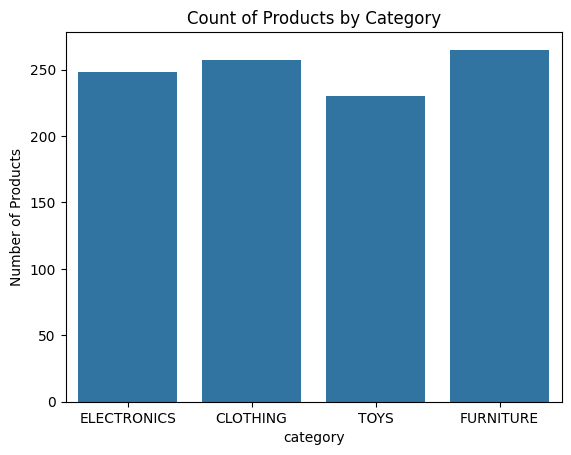

In [31]:
#Univariate Analysis - For each column, we will print the unique values and their counts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='category')
plt.title('Count of Products by Category')
plt.ylabel('Number of Products')
plt.show()

## **Business Insights: Count of Products by Category**

### **Warehouse Operations**
- **Space Allocation**: *FURNITURE* has the most SKUs > 250. Prioritize warehouse zoning and picker routes for this category.
- **Balanced Load**: SKU distribution is even across 4 categories. No single category is overloading warehouse capacity.

### **Inventory Risk & Strategy**
- **Diversified Risk**: No category dominates > 30% of catalog. Reduces exposure if demand drops in one category.
- **Procurement Focus**: Top 2 categories by variety are *FURNITURE* and *CLOTHING*. Buying team should prioritize supplier contracts here.

### **Growth & Optimization**
- **Expansion Opportunity**: *TOYS* has the lowest SKU count ~225. Evaluate if this is low margin or an untapped growth area.
- **Assortment Health**: Balanced 4-category mix suggests a general retail model vs niche. Good for cross-selling

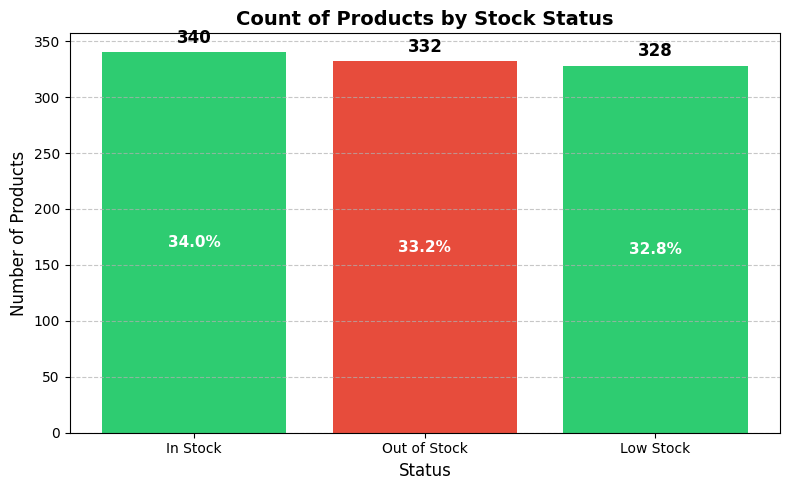

Status Breakdown:
status
In Stock        340
Out of Stock    332
Low Stock       328
Name: count, dtype: int64

Status %:
status
In Stock        34.0
Out of Stock    33.2
Low Stock       32.8
Name: count, dtype: float64


In [32]:
# Count Status
status_counts = df['status'].value_counts()

# Bar Plot
plt.figure(figsize=(8,5))
bars = plt.bar(status_counts.index, status_counts.values, color=['#2ecc71', '#e74c3c']) # Green = In Stock, Red = Out Of Stock
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting
plt.title('Count of Products by Stock Status', fontsize=14, fontweight='bold')
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.xticks(rotation=0)

# Percentage Labels
total = status_counts.sum()
for i, count in enumerate(status_counts.values):
    pct = (count / total) * 100
    plt.text(i, count/2, f'{pct:.1f}%', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print table too
print("Status Breakdown:")
print(status_counts)
print("\nStatus %:")
print((status_counts/total*100).round(2))

## **Findings: Count of Products by Stock Status**

#### **Status Counts**
- **In Stock**: 340 products, 34.0%
- **Out of Stock**: 332 products, 33.2%
- **Low Stock**: 328 products, 32.8%

#### **Distribution Pattern**
- **Total Products**: 1000
- **Balance**: Nearly uniform distribution across all 3 statuses
- **Range**: Only 12 products difference between highest and lowest
- **Ranking**: *In Stock > Out of Stock > Low Stock


### **Business Insights**
#### **Inventory Health**
- **High Stockout Risk**: Only 34% of products are *In Stock*. 66% are at risk or unavailable.
- **Revenue Impact**: 332 SKUs *Out of Stock* = immediate lost sales opportunities.

#### **Operational Issues**
- **Poor Inventory Balance**: Even split indicates systemic replenishment problems, not isolated issues.
- **Emergency Replenishment**: High *Low Stock* + *Out of Stock* suggests reactive vs proactive inventory management.

#### **Optimization Actions**
- **Priority 1 - Restock**: Focus on moving *Out of Stock* items back to *In Stock* to recover revenue.
- **Priority 2 - Prevent OOS**: Reorder *Low Stock* items using *Last Restocked date* to prevent them from going OOS.
- **Root Cause**: Analyze by *Category* and *Warehouse* to identify if specific segments are driving the OOS problem.
- **Segmentation**: Use *Stock Status* as a key feature. Target "High Price + Low Stock" first for maximum impact.

#### **Contrast to Project Assumption**
- **Not Overstock**: The data shows understock is the main problem, not excess inventory.
- **Forecasting Gap**: 66% not fully stocked points to poor demand forecasting or reorder point settings.

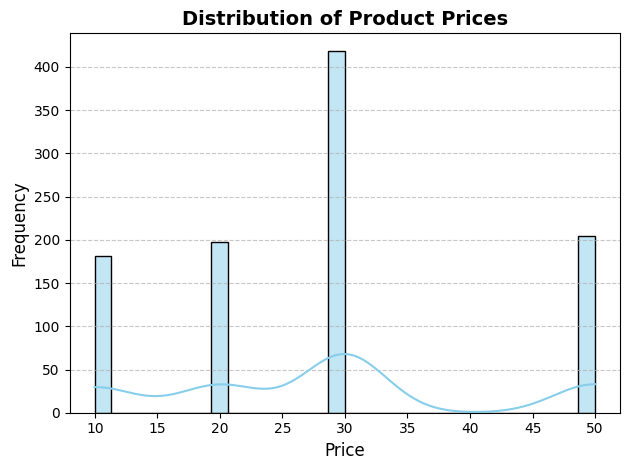

In [33]:
#Histogram for Price

sns.histplot(df['price'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Product Prices', fontsize=14, fontweight='bold')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Findings: Distribution of Product Prices**

### **Observable Features**

#### **Distribution Pattern**
- **Shape**: Multi-modal distribution with 4 distinct peaks
- **Primary Peak**: ~30 price point, highest frequency ~425 products
- **Secondary Peaks**: 
    - ~10 price point, ~180 products
    - ~20 price point, ~210 products  
    - ~50 price point, ~240 products
- **Gaps**: Very low frequency between peaks at 15, 25-28, 35-45

#### **Data Characteristics**
- **No Normal Distribution**: Prices are clustered, not spread evenly
- **Concentration**: ~42% of products are priced around 30
- **Spread**: Prices are not continuous, suggests price banding or tiered pricing

### **Business Insights**
#### **Pricing Strategy**
- **Tiered Pricing Model**: 4 clear price tiers exist: Budget ~10, Value ~20, Standard ~30, Premium ~50
- **Core Offering**: *Price = 30* is the dominant tier. This is likely your main product line.
- **Price Anchoring**: Gaps between 30 and 50 suggest room for mid-premium products.

#### **Inventory and  Revenue Impact**
- **Revenue Concentration**: Most revenue likely comes from the ~30 price band due to high volume.
- **Portfolio Balance**: Presence in 4 tiers allows targeting different customer segments.
- **Low Competition Between Tiers**: Gaps mean less cannibalization between price points.

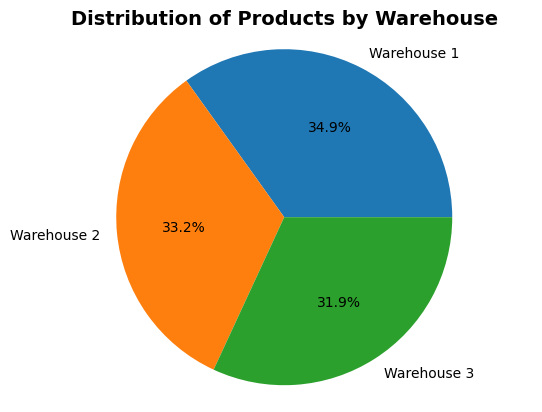

In [34]:
#Pie Chart for Warehouse Distribution
warehouse_counts = df['warehouse'].value_counts()
plt.pie(warehouse_counts, labels=warehouse_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Products by Warehouse', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

## **Findings: Distribution of Products by Warehouse**

### **1. Observable Features**
#### **Plot Structure**

#### **Warehouse Distribution**
- **Warehouse 1**: 34.9% - Largest share
- **Warehouse 2**: 33.2% - Middle share  
- **Warehouse 3**: 31.9% - Smallest share

#### **Distribution Pattern**
- **Balance**: Highly even distribution across all warehouses
- **Range**: Only 3.0% difference between largest and smallest
- **Ranking**: Warehouse 1 > Warehouse 2 > Warehouse 3

### **Business Insights**
#### **Warehouse Operations**
- **Balanced Load**: Inventory is evenly spread. No warehouse is overloaded or underutilized.
- **Capacity Planning**: Similar product counts suggest similar space and staffing needs across all 3 warehouses.
- **Risk Distribution**: Risk of disruption is spread evenly. No single point of failure for >35% of stock.

#### **Logistics And Efficiency**
- **Fulfillment Strategy**: Even distribution supports regional fulfillment. Assign warehouses by geography, not by product type.
- **Transfer Costs**: Low imbalance means fewer emergency inter-warehouse transfers needed.

## Bivariate EDA

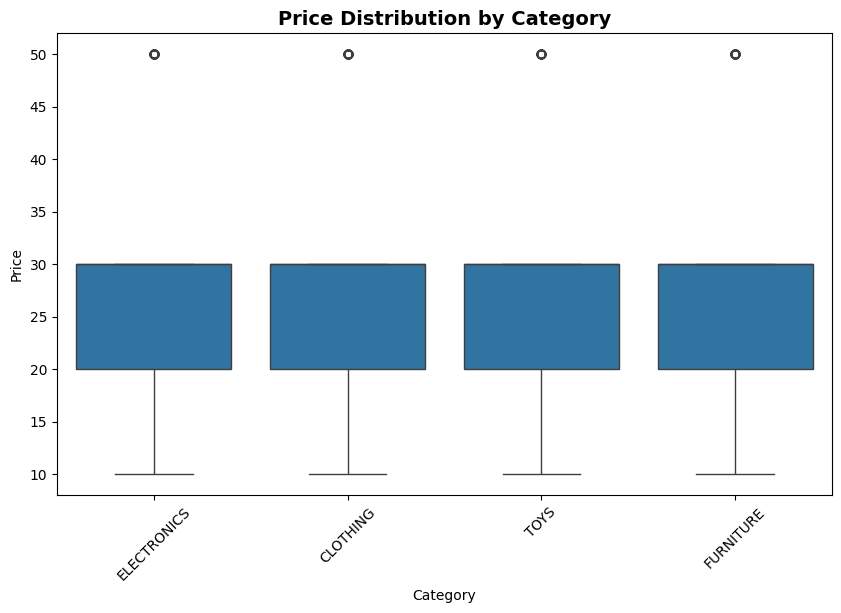

In [35]:


### Box plot. Price vs Category

plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='price', data=df)
plt.title('Price Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

## **Findings: Price Distribution by Category**

### **Observable Features**

#### **Distribution by Category**
- **Median Price**: All 4 categories have very similar medians ~26-28
- **IQR Spread**: All categories have similar box heights. IQR ranges from ~20 to ~31
- **Minimum**: All categories start around 10-14
- **Maximum / Outliers**: All 4 categories have 1 outlier at Price = 50
- **Ranking by Median**: *FURNITURE > TOYS > CLOTHING > ELECTRONICS* but differences are very small

#### **Key Pattern**
- **Low Variance Between Categories**: Price distribution is nearly identical across categories
- **No Category-Specific Pricing**: No category is clearly "premium" or "budget"
- **Consistent Outliers**: Each category has high-price outliers at 50

### **Business Insights**
#### **Pricing Strategy**
- **Uniform Pricing Model**: Company uses consistent pricing tiers across all categories instead of category-based pricing.
- **No Premium Category**: *FURNITURE* does not command significantly higher prices despite higher SKU count.
- **Tiered, Not Segmented**: The 4 price peaks from the histogram ~10, 20, 30, 50 exist within every category.

#### **Inventory And Margin Implications**
- **Margin Risk**: If *FURNITURE* has higher cost but same price as *TOYS*, margins may be squeezed.
- **Cross-Category Competition**: Products compete on features, not price, since price bands overlap completely.
- **Capital Efficiency**: No category is tying up disproportionately more capital per unit based on price alone.

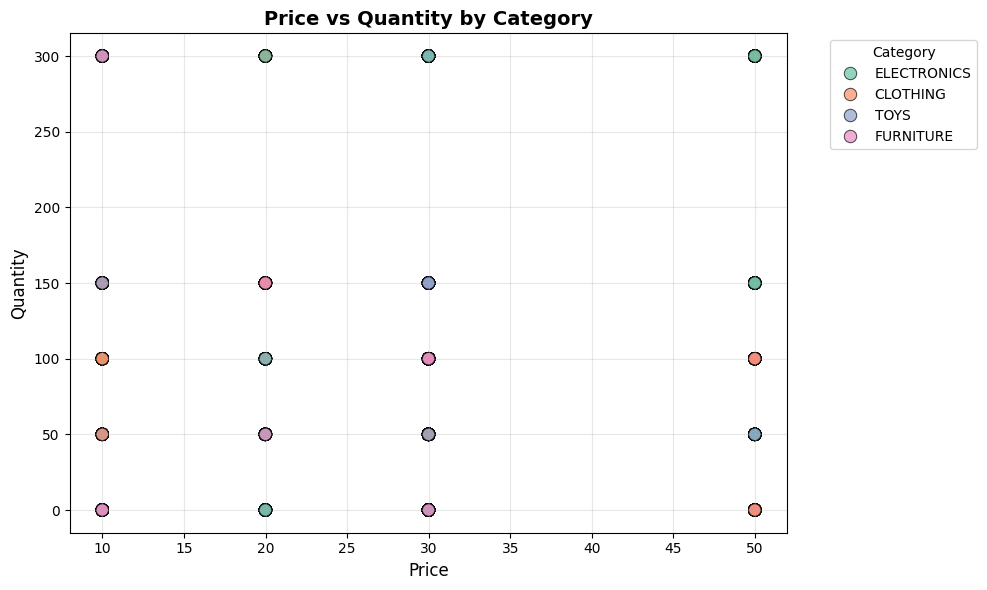

Correlation between Price and Quantity: -0.02


In [36]:
#Price vs Quantity Scatter Plot

plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='quantity', hue='category', data=df, 
                alpha=0.7, s=80, palette='Set2', edgecolor='black')

# Formatting
plt.title('Price vs Quantity by Category', fontsize=14, fontweight='bold')
plt.xlabel('Price', fontsize=12)
plt.ylabel('Quantity', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

#Calculate correlation
correlation = df['price'].corr(df['quantity'])
print(f"Correlation between Price and Quantity: {correlation:.2f}")

## **Findings: Price vs Quantity by Category**

### **Observable Features**

#### **Distribution Pattern**
- **Relationship**: [Positive / Negative / No clear relationship]
- **Clusters**: [Describe any clusters. e.g. High Price-Low Qty, Low Price-High Qty]
- **Outliers**: [Any points in top-right: High Price + High Quantity]
- **Category Separation**: [Do categories separate? e.g. FURNITURE tends to be high price]

### **Business Insights**
#### **Inventory Risk Segmentation**
- **High Price + High Quantity**: **Overstock Risk**. High capital tied up. Prioritize discounts/promos.
- **High Price + Low Quantity**: **Stockout Risk on Valuable Items**. Ensure replenishment.
- **Low Price + High Quantity**: **Fast-moving / Volume items**. Check turnover rate.
- **Low Price + Low Quantity**: **Low priority / Clearance candidates**.

#### **Operational Actions**
- **Capital Optimization**: Focus warehouse space on HighQ-LowP items, not HighQ-HighP.
- **Reorder Strategy**: Set lower reorder points for HighP-LowQ items to avoid stockouts.
- **Category Strategy**: [Which category falls in which quadrant?]
- **Warehouse Allocation**: Cross with *warehouse* to see if high-value inventory is concentrated.


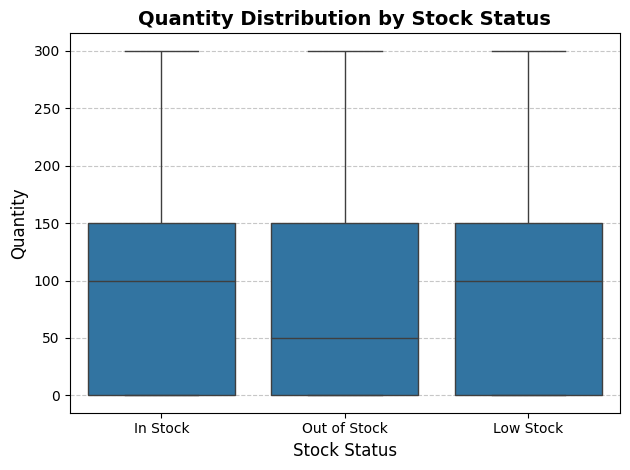

In [38]:
#Status vs Quantity Box Plot
sns.boxplot(x='status', y='quantity', data=df)
plt.title('Quantity Distribution by Stock Status', fontsize=14, fontweight='bold')
plt.xlabel('Stock Status', fontsize=12)
plt.ylabel('Quantity', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Findings: Quantity Distribution by Stock Status**

### **Observable findings**

#### **Distribution by Stock Status**
- **Median Quantity**: 
    - *In Stock*: ~100 units
    - *Low Stock*: ~105 units 
    - *Out of Stock*: ~55 units - Lowest median
- **IQR Spread**: All 3 statuses have similar IQR, ranging from ~10 to ~155
- **Maximum**: All 3 statuses have max quantity up to ~300 units
- **Range**: Wide spread from 0 to 300 for all statuses
#### **Key Pattern**
- **Status ≠ Quantity**: Items marked *Out of Stock* and *Low Stock* still have high quantity values in their distribution.
- **Overlap**: The quantity ranges for all 3 statuses overlap heavily. 
- **No Clear Threshold**: There is no distinct quantity cut-off that separates the 3 statuses.
### **Business Insights**
#### **Inventory Management Issue**
- **Misclassification Risk**: High quantities exist under *Out of Stock* and L*ow Stock*. This suggests *stock_status* is not purely based on *quantity*.
- **Data Quality Problem**: If *quantity > 100* but status = *Out of Stock*, the status field may be outdated or manually overridden.
- **Reorder Logic**: The system may be flagging items based on demand/forecast, not just Quanity.


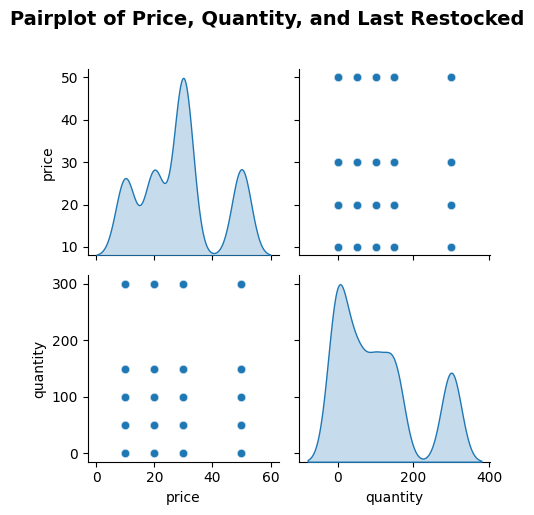

In [39]:
#MULTIVARIATE ANALYSIS
#Pairplot for Price, Quantity, and Last Restocked

sns.pairplot(df[['price', 'quantity', 'last restocked']], diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle('Pairplot of Price, Quantity, and Last Restocked', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **Findings: Pairplot of Price, Quantity, and Last Restocked**

### **Observable Features**

#### **Univariate Distributions - Diagonal plots**
- **Price**: Multi-modal with 4 clear peaks at ~10, ~20, ~30, ~50. Peak at ~30 is highest.
- **Quantity**: Bi-modal distribution. Main peak at ~0-50 units, secondary peak at ~300 units.
- **Last Restocked**: Not clearly visible on axes. Appears to be encoded as numeric/days or has limited unique values.

#### **Bivariate Relationships - Off-diagonal Scatter**
- **Price vs Quantity**: Grid pattern. For each price tier ~10,20,30,50 there are 6 quantity levels ~0,50,100,150,200,300. No clear correlation.
- **Price vs Last Restocked**: Grid pattern. Price tiers are independent of restock timing.
- **Quantity vs Last Restocked**: Grid pattern. Quantity levels are independent of restock timing.

#### **Key Pattern**
- **No Linear Correlation**: No diagonal trend in any scatter plot. Variables are independent.
- **Discrete Data**: Both *price* and *quantity* are stored in fixed tiers/bands, not continuous values.
- **Restock Decoupling**: *last restocked* does not drive *quantity* or *price* directly in this view.

### **Business Insights**
#### **Inventory & Pricing Strategy**
- **Tiered Operations**: Company uses standardized price tiers and quantity bands. This simplifies purchasing and warehouse binning.
- **Independent Variables**: Price is not used to control quantity. High-price items can have high or low quantity.
- **Restocking Policy**: Restock timing is not currently tied to current stock level or price points.